In [57]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

SEED = 42
MIN_OBSERVED_TARGETS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


set_global_seed(SEED)

X_cols = [
    "Construction period",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Country",
]

y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

In [58]:
QUANTILES = [0.05, 0.50, 0.95]  # p5, p50, p95


def split_inputs(x_full: torch.Tensor, structure_dim: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Split encoded features into trunk input and explicit structure features."""
    if structure_dim <= 0 or structure_dim >= x_full.shape[1]:
        raise ValueError(
            f"Invalid structure_dim={structure_dim} for input width={x_full.shape[1]}"
        )
    x_all = x_full[:, :-structure_dim]
    x_structure = x_full[:, -structure_dim:]
    return x_all, x_structure


class JointQuantileNet(nn.Module):
    """
    Shared-trunk multi-task quantile network with explicit structure-feature concatenation.

    x_all is passed through the trunk, then trunk output is concatenated with
    x_structure before each material head.
    """

    def __init__(
        self,
        input_dim: int,
        structure_dim: int,
        M: int = 5,
        hidden_dim: int = 256,
    ):
        super().__init__()
        self.M = M
        self.structure_dim = structure_dim

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.heads = nn.ModuleList(
            [nn.Linear(hidden_dim + structure_dim, 3) for _ in range(M)]
        )

    def forward(self, x_all: torch.Tensor, x_structure: torch.Tensor) -> torch.Tensor:
        """
        Returns
        -------
        quantiles : Tensor of shape (batch, M, 3)
            dim-2 order: [p5, p50, p95]
        """
        h = self.trunk(x_all)
        h_concat = torch.cat([h, x_structure], dim=1)
        per_material = [head(h_concat) for head in self.heads]  # M × (batch, 3)
        raw = torch.stack(per_material, dim=1)                  # (batch, M, 3)

        q50 = raw[:, :, 0]                                      # (batch, M)
        delta_low = F.softplus(raw[:, :, 1]) + 1e-4             # positive spread
        delta_high = F.softplus(raw[:, :, 2]) + 1e-4

        q5 = q50 - delta_low
        q95 = q50 + delta_high

        return torch.stack([q5, q50, q95], dim=-1)              # (batch, M, 3)


In [59]:
def quantile_loss(
    y_pred: torch.Tensor,   # (batch, M, 3)  — [p5, p50, p95] in log1p space
    y_true: torch.Tensor,   # (batch, M)     — log1p targets, 0 where unobserved
    y_mask: torch.Tensor,   # (batch, M) bool
) -> torch.Tensor:
    """
    Masked pinball (quantile) loss averaged over observed (material, quantile) pairs.

    For each observed (row, material) pair the pinball loss is computed for
    all three quantile levels and summed.  Unobserved materials contribute
    zero to the numerator and denominator.
    """
    q_levels = y_true.new_tensor(QUANTILES)          # (3,)
    y_true_exp = y_true.unsqueeze(-1)                # (batch, M, 1)

    errors = y_true_exp - y_pred                     # (batch, M, 3)
    # pinball: max(q*e, (q-1)*e)
    pinball = torch.where(
        errors >= 0,
        q_levels * errors,
        (q_levels - 1) * errors,
    )                                                # (batch, M, 3)

    # broadcast mask over quantile dimension
    mask = y_mask.unsqueeze(-1).float()              # (batch, M, 1)
    masked_sum = (pinball * mask).sum()
    n_observed = mask.sum() * len(QUANTILES)

    return masked_sum / (n_observed + 1e-8)


In [60]:
def prepare_dataloaders(
    file_path: str | Path = "Integrated_MI_database.xlsx",
    batch_size: int = 64,
    random_state: int = SEED,
    clip_upper_quantile: float | None = 0.99,
    clip_materials: tuple[str, ...] = ("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets: int = MIN_OBSERVED_TARGETS,
 ):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)

    df["Construction period"] = pd.to_numeric(
        df["Construction period"], errors="coerce"
    )
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    split_data = train_test_split(
        X, y_raw_df, y_mask, test_size=0.30, random_state=random_state
    )
    X_train, X_temp, y_train_raw_df, y_temp_raw_df, y_train_mask, y_temp_mask = split_data

    split_temp = train_test_split(
        X_temp, y_temp_raw_df, y_temp_mask, test_size=0.50, random_state=random_state
    )
    X_val, X_test, y_val_raw_df, y_test_raw_df, y_val_mask, y_test_mask = split_temp

    X_train = X_train.reset_index(drop=True)
    X_val = X_val.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train_raw_df = y_train_raw_df.reset_index(drop=True)
    y_val_raw_df = y_val_raw_df.reset_index(drop=True)
    y_test_raw_df = y_test_raw_df.reset_index(drop=True)

    # Force writable buffers so percentile clipping can assign in-place.
    y_train_raw = np.array(y_train_raw_df.to_numpy(dtype=np.float32), copy=True)
    y_val_raw = np.array(y_val_raw_df.to_numpy(dtype=np.float32), copy=True)
    y_test_raw = np.array(y_test_raw_df.to_numpy(dtype=np.float32), copy=True)

    clip_bounds = None
    if clip_upper_quantile is not None:
        if not (0.0 <= clip_upper_quantile <= 1.0):
            raise ValueError("clip_upper_quantile must satisfy 0 <= q <= 1")

        material_to_idx = {material: idx for idx, material in enumerate(y_cols)}
        selected_materials = [
            material for material in clip_materials if material in material_to_idx
        ]

        upper_bounds = {}
        for material in selected_materials:
            idx = material_to_idx[material]
            observed_train = y_train_mask[:, idx]
            if not np.any(observed_train):
                continue

            upper_bound = np.quantile(
                y_train_raw[observed_train, idx], clip_upper_quantile
            )

            for target_array, target_mask in (
                (y_train_raw, y_train_mask),
                (y_val_raw, y_val_mask),
                (y_test_raw, y_test_mask),
            ):
                observed_rows = target_mask[:, idx]
                target_array[observed_rows, idx] = np.minimum(
                    target_array[observed_rows, idx], upper_bound
                )

            upper_bounds[material] = float(upper_bound)

        clip_bounds = {
            "upper_quantile": clip_upper_quantile,
            "upper_bounds": upper_bounds,
        }

    y_train_filled = np.nan_to_num(y_train_raw, nan=0.0)
    y_val_filled = np.nan_to_num(y_val_raw, nan=0.0)
    y_test_filled = np.nan_to_num(y_test_raw, nan=0.0)

    y_train = np.where(y_train_mask, np.log1p(y_train_filled), 0.0).astype(np.float32)
    y_val = np.where(y_val_mask, np.log1p(y_val_filled), 0.0).astype(np.float32)
    y_test = np.where(y_test_mask, np.log1p(y_test_filled), 0.0).astype(np.float32)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ["Construction period"]),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ["Typology", "Primary Code", "Hybrid Structure", "Country"],
            ),
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    # Explicit structure feature width from OneHot categories of "Hybrid Structure".
    structure_dim = len(preprocessor.named_transformers_["cat"].categories_[2])

    X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    y_train_mask_tensor = torch.tensor(y_train_mask, dtype=torch.bool)
    y_val_mask_tensor = torch.tensor(y_val_mask, dtype=torch.bool)
    y_test_mask_tensor = torch.tensor(y_test_mask, dtype=torch.bool)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor, y_train_mask_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor, y_val_mask_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor, y_test_mask_tensor)

    loader_kwargs = {"pin_memory": torch.cuda.is_available()}
    train_generator = torch.Generator().manual_seed(random_state)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs
    )

    return {
        "X_train": X_train_tensor,
        "X_val": X_val_tensor,
        "X_test": X_test_tensor,
        "y_train": y_train_tensor,
        "y_val": y_val_tensor,
        "y_test": y_test_tensor,
        "y_train_mask": y_train_mask_tensor,
        "y_val_mask": y_val_mask_tensor,
        "y_test_mask": y_test_mask_tensor,
        "y_val_raw_df": y_val_raw_df,
        "y_test_raw_df": y_test_raw_df,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "preprocessor": preprocessor,
        "clip_bounds": clip_bounds,
        "kept_rows": len(df),
        "min_observed_targets": min_observed_targets,
        "structure_dim": structure_dim,
    }


In [61]:
data = prepare_dataloaders()
print("Data preparation complete.")
print(f"X_train shape: {data['X_train'].shape}, y_train shape: {data['y_train'].shape}")
print(f"X_val shape:   {data['X_val'].shape}, y_val shape:   {data['y_val'].shape}")
print(f"X_test shape:  {data['X_test'].shape}, y_test shape:  {data['y_test'].shape}")
print(
    f"Rows kept with >= {data['min_observed_targets']} observed targets: {data['kept_rows']}"
 )

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"].cpu().numpy()
    observed_counts = mask.sum(axis=1)
    print(
        f"{split.title()} observed targets per row - "
        f"min: {observed_counts.min()}, "
        f"mean: {observed_counts.mean():.2f}, "
        f"max: {observed_counts.max()}"
    )

Data preparation complete.
X_train shape: torch.Size([1743, 46]), y_train shape: torch.Size([1743, 5])
X_val shape:   torch.Size([373, 46]), y_val shape:   torch.Size([373, 5])
X_test shape:  torch.Size([374, 46]), y_test shape:  torch.Size([374, 5])
Rows kept with >= 2 observed targets: 2490
Train observed targets per row - min: 2, mean: 3.70, max: 5
Val observed targets per row - min: 2, mean: 3.66, max: 5
Test observed targets per row - min: 2, mean: 3.74, max: 5


In [62]:
def quantile_loss(pred_q, target, q):
    e = target - pred_q
    return torch.maximum((q - 1) * e, q * e)


def masked_multi_quantile_loss(preds, y, mask, quantiles=QUANTILES):
    # preds: (B, M, Q), y/mask: (B, M)
    B, M, Q = preds.shape
    losses = []
    valid_count = 0

    for m in range(M):
        m_mask = mask[:, m]  # (B,)
        if m_mask.any():
            y_m = y[m_mask, m]  # (N,)
            pred_m = preds[m_mask, m, :]  # (N, Q)
            lq = 0.0
            for qi, q in enumerate(quantiles):
                lq = lq + quantile_loss(pred_m[:, qi], y_m, q).mean()
            losses.append(lq / Q)
            valid_count += 1

    if valid_count == 0:
        return torch.tensor(0.0, device=preds.device, requires_grad=True)

    return torch.stack(losses).mean()


def train_one_epoch(model, loader, optimizer, structure_dim: int):
    model.train()
    total = 0.0
    n = 0
    for X_batch, y_batch, m_batch in loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        m_batch = m_batch.to(DEVICE, non_blocking=True)

        x_all, x_structure = split_inputs(X_batch, structure_dim)
        optimizer.zero_grad(set_to_none=True)
        preds = model(x_all, x_structure)
        loss = masked_multi_quantile_loss(preds, y_batch, m_batch)
        loss.backward()
        optimizer.step()

        total += loss.item() * X_batch.size(0)
        n += X_batch.size(0)
    return total / max(n, 1)


def evaluate_loss(model, loader, structure_dim: int):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for X_batch, y_batch, m_batch in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            m_batch = m_batch.to(DEVICE, non_blocking=True)

            x_all, x_structure = split_inputs(X_batch, structure_dim)
            preds = model(x_all, x_structure)
            loss = masked_multi_quantile_loss(preds, y_batch, m_batch)

            total += loss.item() * X_batch.size(0)
            n += X_batch.size(0)
    return total / max(n, 1)


def objective(trial):
    tuned_data = prepare_dataloaders(batch_size=trial.suggest_categorical("batch_size", [32, 64, 128]))

    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 384])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    structure_dim = tuned_data["structure_dim"]
    input_dim = tuned_data["X_train"].shape[1] - structure_dim
    model = JointQuantileNet(
        input_dim=input_dim,
        structure_dim=structure_dim,
        M=5,
        hidden_dim=hidden_dim,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    best_val = float("inf")
    epochs = 80
    for _ in range(epochs):
        _ = train_one_epoch(model, tuned_data["train_loader"], optimizer, structure_dim)
        val = evaluate_loss(model, tuned_data["val_loader"], structure_dim)
        if val < best_val:
            best_val = val

    return best_val


study = optuna.create_study(direction="minimize")
n_trials = 20
trial_progress = tqdm(total=n_trials, desc="Optuna trials", leave=True)

def _progress_callback(study, trial):
    trial_progress.update(1)

study.optimize(objective, n_trials=n_trials, callbacks=[_progress_callback])
trial_progress.close()

print("Best trial:")
print(study.best_trial.params)
best_params = study.best_trial.params

# Retrain best model on train split and monitor val
model = JointQuantileNet(
    input_dim=data["X_train"].shape[1] - data["structure_dim"],
    structure_dim=data["structure_dim"],
    M=5,
    hidden_dim=best_params["hidden_dim"],
).to(DEVICE)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)

best_state_dict = None
best_val_loss = float("inf")
epochs = 120

final_epoch_progress = tqdm(range(1, epochs + 1), desc="Final training", leave=True)
for epoch in final_epoch_progress:
    train_loss = train_one_epoch(model, data["train_loader"], optimizer, data["structure_dim"])
    val_loss = evaluate_loss(model, data["val_loader"], data["structure_dim"])
    final_epoch_progress.set_postfix(train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print(f"Best validation loss: {best_val_loss:.6f}")


[I 2026-04-21 11:47:13,937] A new study created in memory with name: no-name-31c331ed-25f6-4c83-8f2c-da87986efe57
Optuna trials: 100%|██████████| 20/20 [03:05<00:00,  9.26s/it]


Best trial:
{'batch_size': 32, 'hidden_dim': 384, 'lr': 0.0012282912615288993, 'weight_decay': 1.998946613289059e-05}


Final training: 100%|██████████| 120/120 [00:12<00:00,  9.96it/s, train_loss=0.1105, val_loss=0.1528]

Best validation loss: 0.142966


In [71]:
def predict_material_ranges(
    model,
    X_new_tensor,
    structure_dim: int,
    conformal_qhats=None,
    quantiles=QUANTILES,
):
    model.eval()
    with torch.no_grad():
        X_new = X_new_tensor.to(DEVICE)
        x_all, x_structure = split_inputs(X_new, structure_dim)
        q_pred = model(x_all, x_structure).cpu().numpy()  # (N, M, 3) in log1p space

    # Restore predictions to physical units (kg/m^3).
    q5 = np.expm1(q_pred[:, :, 0])
    q50 = np.expm1(q_pred[:, :, 1])
    q95 = np.expm1(q_pred[:, :, 2])

    if conformal_qhats is not None:
        # Apply qhat in physical units, consistent with conformal calibration.
        for m, material in enumerate(y_cols):
            qhat = float(conformal_qhats.get(material, 0.0))
            q5[:, m] = np.maximum(q5[:, m] - qhat, 0.0)
            q95[:, m] = q95[:, m] + qhat

    out = {}
    for m, material in enumerate(y_cols):
        out[material] = {
            "p5": q5[:, m],
            "p50": q50[:, m],
            "p95": q95[:, m],
        }
    return out


if (not isinstance(data, dict)) or ("X_test" not in data) or ("structure_dim" not in data):
    print("Rebuilding dataset dictionary because `data` was overwritten in kernel state.")
    data = prepare_dataloaders()

existing_conformal_qhats = globals().get("conformal_qhats")
pred_ranges = predict_material_ranges(
    model,
    data["X_test"],
    structure_dim=data["structure_dim"],
    conformal_qhats=existing_conformal_qhats,
)
for material in y_cols:
    print(
        material,
        "median first3:",
        np.round(pred_ranges[material]["p50"][:3], 3),
        "range first3:",
        np.round(pred_ranges[material]["p5"][:3], 3),
        "-",
        np.round(pred_ranges[material]["p95"][:3], 3),
    )


Concrete median first3: [1683.072 1683.072 1517.225] range first3: [711.842 711.842 825.715] - [2803.118 2803.118 2641.356]
Glass median first3: [2.025 2.025 4.351] range first3: [0.243 0.243 1.423] - [5.544 5.544 8.966]
Steel median first3: [16.68  16.68  34.866] range first3: [ 0.347  0.347 10.879] - [ 41.345  41.345 107.62 ]
Wood median first3: [16.707 16.707 16.946] range first3: [0.    0.    0.422] - [47.616 47.616 51.151]
Brick median first3: [944.722 944.722 402.706] range first3: [515.786 515.786  84.869] - [1491.778 1491.778  866.107]


In [72]:
def fit_conformal_qhats(
    model,
    X_calib_tensor,
    y_calib_raw_df,
    alpha=0.10,
    structure_dim: int = 1,
):
    """
    Split-conformal calibration on val set using CQR nonconformity scores.

    scores_i = max(q_lo(x_i) - y_i, y_i - q_hi(x_i)) on the original target scale.
    Note: scores can be negative if y_i lies well inside [q_lo, q_hi], which enables
    interval shrinking when appropriate.
    """
    # predict_material_ranges already applies expm1, so these are in physical units (kg/m^3).
    base_pred = predict_material_ranges(model, X_calib_tensor, structure_dim=structure_dim)
    qhats = {}

    for material in y_cols:
        y_obs = y_calib_raw_df[material].to_numpy(dtype=float)
        mask = ~np.isnan(y_obs)
        if mask.sum() == 0:
            qhats[material] = 0.0
            continue

        lo = base_pred[material]["p5"][mask]
        hi = base_pred[material]["p95"][mask]
        yv = y_obs[mask]

        # True CQR conformity score (can be negative; do not clip).
        scores = np.maximum(lo - yv, yv - hi)

        n = scores.shape[0]
        q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
        qhat = float(np.quantile(scores, q_level, method="higher"))
        qhats[material] = qhat

    return qhats


def evaluate_conformal_coverage(
    model,
    X_tensor,
    y_raw_df,
    qhats,
    structure_dim: int,
):
    pred = predict_material_ranges(
        model,
        X_tensor,
        structure_dim=structure_dim,
        conformal_qhats=qhats,
    )
    rows = []

    for material in y_cols:
        y_obs = y_raw_df[material].to_numpy(dtype=float)
        mask = ~np.isnan(y_obs)
        if mask.sum() == 0:
            rows.append(
                {
                    "material": material,
                    "coverage": np.nan,
                    "mean_interval_width": np.nan,
                    "n_obs": 0,
                }
            )
            continue

        lo = pred[material]["p5"][mask]
        hi = pred[material]["p95"][mask]
        yv = y_obs[mask]

        coverage = np.mean((yv >= lo) & (yv <= hi))
        mean_width = np.mean(hi - lo)

        rows.append(
            {
                "material": material,
                "coverage": coverage,
                "mean_interval_width": mean_width,
                "n_obs": int(mask.sum()),
            }
        )

    return pd.DataFrame(rows)


# Fit qhats on validation set, evaluate on val/test
conformal_qhats = fit_conformal_qhats(
    model,
    data["X_val"],
    data["y_val_raw_df"],
    alpha=0.10,
    structure_dim=data["structure_dim"],
)
print("Conformal qhats:")
for k, v in conformal_qhats.items():
    print(f"  {k}: {v:.4f}")

val_cov = evaluate_conformal_coverage(
    model,
    data["X_val"],
    data["y_val_raw_df"],
    conformal_qhats,
    structure_dim=data["structure_dim"],
)
test_cov = evaluate_conformal_coverage(
    model,
    data["X_test"],
    data["y_test_raw_df"],
    conformal_qhats,
    structure_dim=data["structure_dim"],
)

print("\nValidation conformal coverage (target ~0.90):")
display(val_cov)
print("\nTest conformal coverage:")
display(test_cov)

# store for downstream cells
conformal_bundle = {
    "alpha": 0.10,
    "qhats": conformal_qhats,
    "val_coverage": val_cov,
    "test_coverage": test_cov,
}


Conformal qhats:
  Concrete: 92.5443
  Glass: 0.7927
  Steel: 5.1924
  Wood: 4.4575
  Brick: 9.1822

Validation conformal coverage (target ~0.90):


,material,coverage,mean_interval_width,n_obs
0,Concrete,0.903915,2081.984863,281
1,Glass,0.909605,6.952203,177
2,Steel,0.903727,99.659729,322
3,Wood,0.907407,50.646370,324
4,Brick,0.903846,1050.959473,260



Test conformal coverage:


,material,coverage,mean_interval_width,n_obs
0,Concrete,0.903780,2173.154297,291
1,Glass,0.919786,6.875349,187
2,Steel,0.932153,93.823769,339
3,Wood,0.952381,50.957668,315
4,Brick,0.898113,1075.775269,265


Conformal qhats: {'Concrete': 92.54426179108816, 'Glass': 0.7926777648925782, 'Steel': 5.192360610961913, 'Wood': 4.457525978088379, 'Brick': 9.182151260375978}


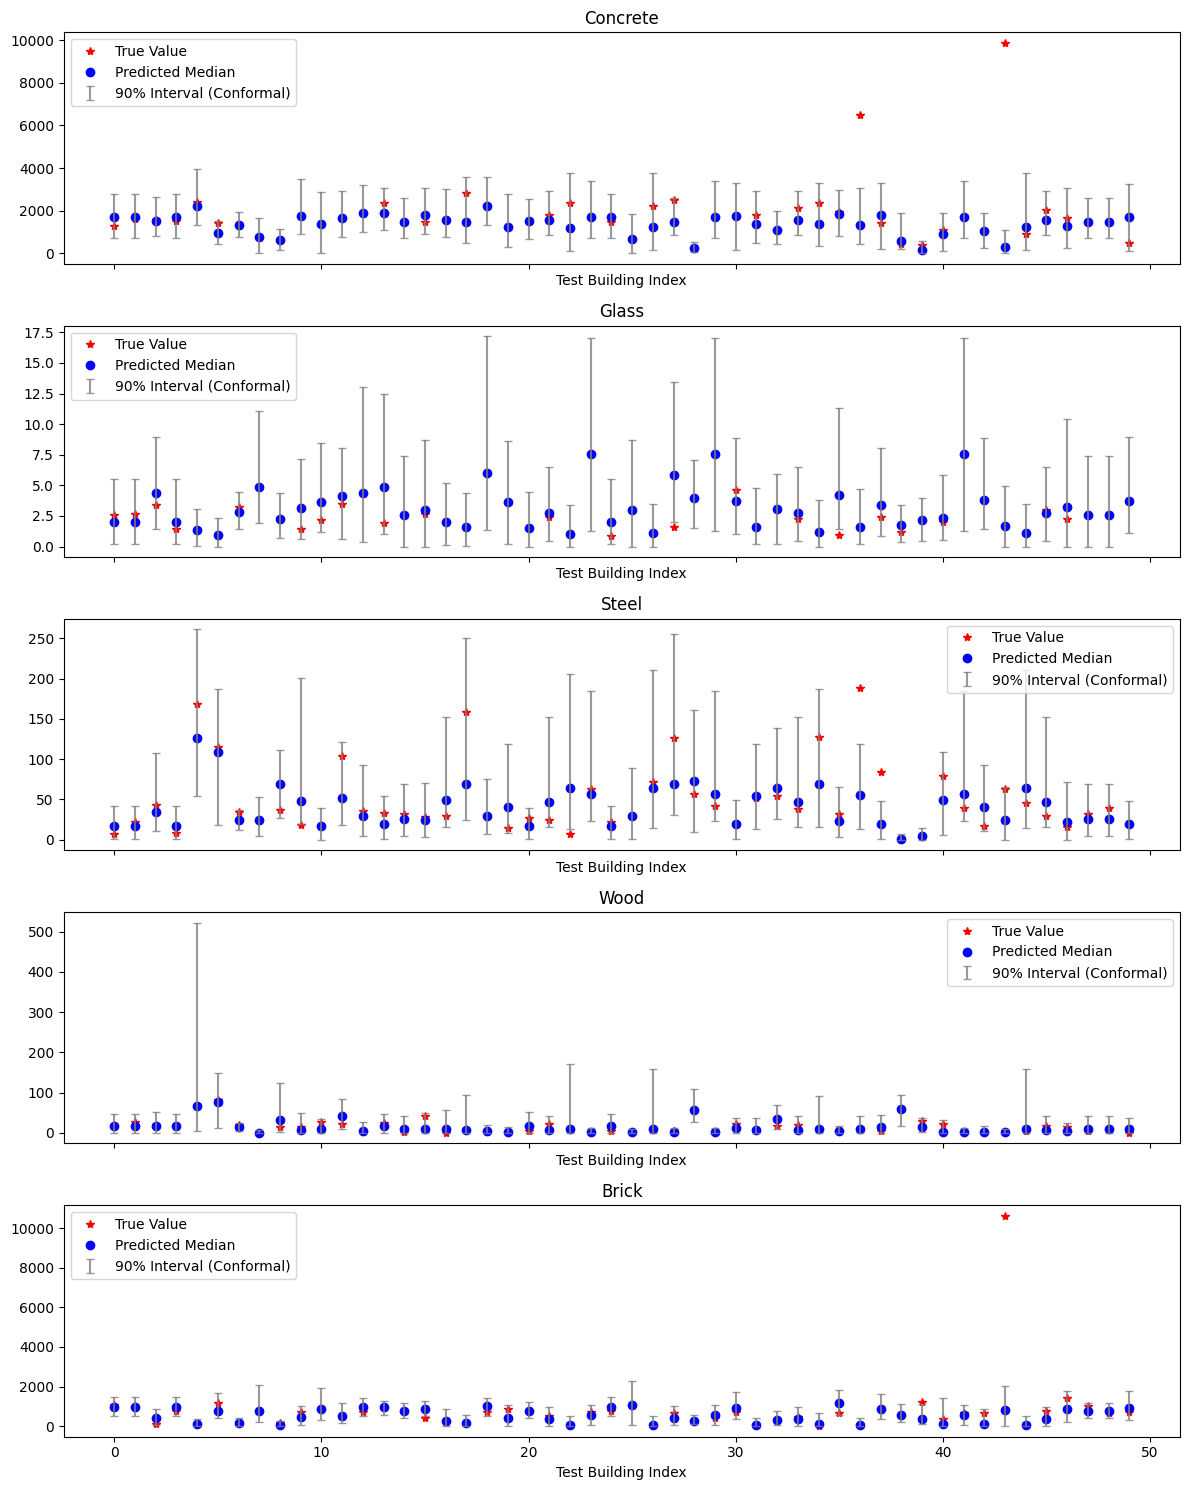

In [79]:
import matplotlib.pyplot as plt

# Validation split is used as calibration data for split-conformal intervals.
y_val_df = data["y_val_raw_df"].copy()
conformal_qhats = fit_conformal_qhats(
    model,
    data["X_val"],
    y_val_df,
    alpha=0.10,
    structure_dim=data["structure_dim"],
)
conformal_bundle = {"alpha": 0.10, "qhats": conformal_qhats}
print("Conformal qhats:", conformal_qhats)

y_test_df = data["y_test_raw_df"].copy()
y_test_mask = data["y_test_mask"].cpu().numpy()

# Predict calibrated ranges for the first 50 buildings in the test set
X_test_first50 = data["X_test"][:50]
pred_ranges = predict_material_ranges(
    model,
    X_test_first50,
    structure_dim=data["structure_dim"],
    conformal_qhats=conformal_qhats,
)

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
x_idx = np.arange(50)

for i, material in enumerate(y_cols):
    ax = axes[i]
    y_true = np.array(y_test_df[material].iloc[:50].to_numpy(dtype=float), copy=True)
    observed = y_test_mask[:50, i].astype(bool)
    y_true[~observed] = np.nan

    y_med = pred_ranges[material]["p50"]
    y_low = pred_ranges[material]["p5"]
    y_high = pred_ranges[material]["p95"]

    ax.plot(x_idx, y_true, "r*", label="True Value")
    ax.plot(x_idx, y_med, "bo", label="Predicted Median")
    ax.errorbar(
        x_idx,
        y_med,
        yerr=[y_med - y_low, y_high - y_med],
        fmt="none",
        ecolor="gray",
        alpha=0.8,
        capsize=3,
        label="90% Interval (Conformal)",
    )

    ax.set_title(material)
    ax.set_xlabel("Test Building Index")
    ax.legend()

plt.tight_layout()
plt.show()

In [81]:
def evaluate_mdn_intervals(model, data, conformal_qhats=None, split="test", structure_dim: int = 1):
    X = data[f"X_{split}"]
    y_true_df = data[f"y_{split}_raw_df"]
    pred_ranges = predict_material_ranges(
        model,
        X,
        structure_dim=structure_dim,
        conformal_qhats=conformal_qhats,
    )

    rows = []
    for material in y_cols:
        y_true = y_true_df[material].to_numpy(dtype=float)
        mask = ~np.isnan(y_true)
        if mask.sum() == 0:
            continue

        lo = pred_ranges[material]["p5"][mask]
        hi = pred_ranges[material]["p95"][mask]
        med = pred_ranges[material]["p50"][mask]
        yt = y_true[mask]

        coverage = np.mean((yt >= lo) & (yt <= hi))
        width = np.mean(hi - lo)
        mae = np.mean(np.abs(med - yt))

        rows.append({"material": material, "coverage": coverage, "mean_width": width, "mae": mae})

    return pd.DataFrame(rows)


eval_df = evaluate_mdn_intervals(
    model,
    data,
    conformal_qhats=conformal_qhats,
    split="test",
    structure_dim=data["structure_dim"],
)
print(eval_df)


   material  coverage   mean_width         mae
0  Concrete  0.903780  2173.154297  538.488187
1     Glass  0.919786     6.875349    1.472334
2     Steel  0.932153    93.823769   18.828733
3      Wood  0.952381    50.957668    9.722905
4     Brick  0.898113  1075.775269  284.643596


Joint distribution summary:
  split: test
  n_complete_rows: 146
  mean_vector_mae: 41.746796
  cov_fro_norm: 443453.364040
  corr_fro_norm: 1.098063
  kl_true_to_pred: 13.414061
  kl_pred_to_true: 2.187075

Per-material moments (complete-case rows):


,material,true_mean,pred_mean,abs_mean_diff,true_std,pred_std,abs_std_diff
0,Concrete,1725.538893,1535.441162,190.097731,766.415755,381.000885,385.414870
1,Glass,2.975471,3.112965,0.137494,2.559788,1.113516,1.446272
2,Steel,27.037905,24.402264,2.635641,26.802021,15.296824,11.505197
3,Wood,21.057702,17.869877,3.187826,16.452940,15.650710,0.802230
4,Brick,677.663337,690.338623,12.675286,296.868163,294.295044,2.573119


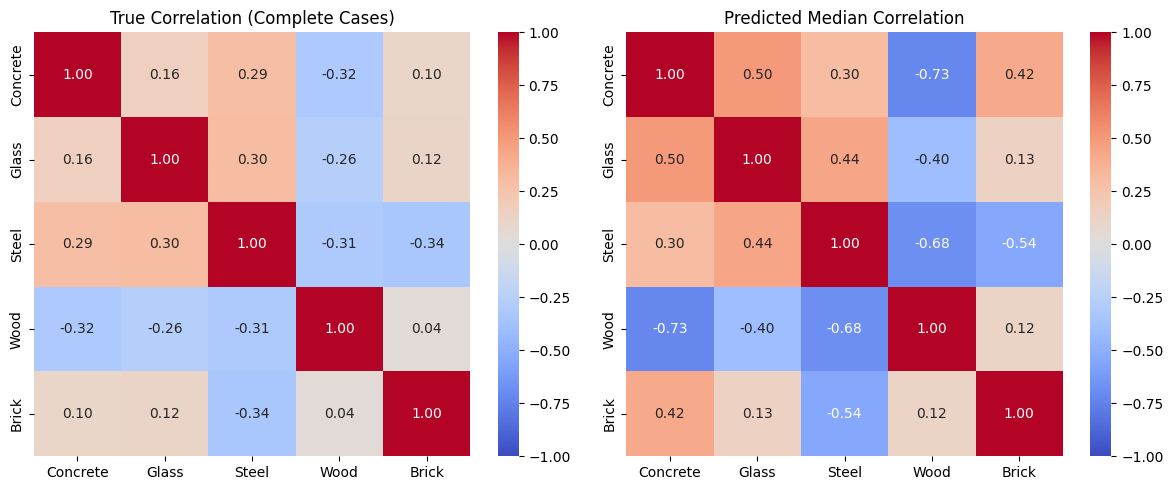

In [82]:
def _gaussian_kl(mu_p, cov_p, mu_q, cov_q, eps=1e-6):
    d = mu_p.shape[0]
    cov_p_reg = cov_p + np.eye(d) * eps
    cov_q_reg = cov_q + np.eye(d) * eps

    sign_p, logdet_p = np.linalg.slogdet(cov_p_reg)
    sign_q, logdet_q = np.linalg.slogdet(cov_q_reg)
    if sign_p <= 0 or sign_q <= 0:
        return np.nan

    inv_q = np.linalg.inv(cov_q_reg)
    mean_term = (mu_q - mu_p).T @ inv_q @ (mu_q - mu_p)
    trace_term = np.trace(inv_q @ cov_p_reg)
    return 0.5 * (trace_term + mean_term - d + (logdet_q - logdet_p))


def evaluate_joint_distribution(
    model,
    data,
    split="test",
    structure_dim: int = 1,
    min_complete_rows: int = 30,
):
    y_df = data[f"y_{split}_raw_df"][y_cols].copy()
    complete_mask = y_df.notna().all(axis=1).to_numpy()
    n_complete = int(complete_mask.sum())

    if n_complete < min_complete_rows:
        raise ValueError(
            f"Not enough complete rows for joint evaluation: {n_complete} < {min_complete_rows}"
        )

    pred_ranges_full = predict_material_ranges(
        model,
        data[f"X_{split}"],
        structure_dim=structure_dim,
        conformal_qhats=None,  # evaluate dependence using central predictions only
    )

    pred_med_full = np.column_stack([pred_ranges_full[m]["p50"] for m in y_cols])
    y_true_full = y_df.to_numpy(dtype=float)

    y_true = y_true_full[complete_mask]
    y_pred = pred_med_full[complete_mask]

    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    std_true = y_true.std(axis=0, ddof=1)
    std_pred = y_pred.std(axis=0, ddof=1)

    cov_true = np.cov(y_true, rowvar=False)
    cov_pred = np.cov(y_pred, rowvar=False)
    corr_true = np.corrcoef(y_true, rowvar=False)
    corr_pred = np.corrcoef(y_pred, rowvar=False)

    summary = {
        "split": split,
        "n_complete_rows": n_complete,
        "mean_vector_mae": float(np.mean(np.abs(mu_true - mu_pred))),
        "cov_fro_norm": float(np.linalg.norm(cov_true - cov_pred, ord="fro")),
        "corr_fro_norm": float(np.linalg.norm(corr_true - corr_pred, ord="fro")),
        "kl_true_to_pred": float(_gaussian_kl(mu_true, cov_true, mu_pred, cov_pred)),
        "kl_pred_to_true": float(_gaussian_kl(mu_pred, cov_pred, mu_true, cov_true)),
    }

    per_material = pd.DataFrame(
        {
            "material": y_cols,
            "true_mean": mu_true,
            "pred_mean": mu_pred,
            "abs_mean_diff": np.abs(mu_true - mu_pred),
            "true_std": std_true,
            "pred_std": std_pred,
            "abs_std_diff": np.abs(std_true - std_pred),
        }
    )

    return summary, per_material, corr_true, corr_pred


joint_summary, joint_per_material, corr_true, corr_pred = evaluate_joint_distribution(
    model,
    data,
    split="test",
    structure_dim=data["structure_dim"],
)

print("Joint distribution summary:")
for k, v in joint_summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.6f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-material moments (complete-case rows):")
display(joint_per_material)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(
    corr_true,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=y_cols,
    yticklabels=y_cols,
    ax=axes[0],
)
axes[0].set_title("True Correlation (Complete Cases)")

sns.heatmap(
    corr_pred,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=y_cols,
    yticklabels=y_cols,
    ax=axes[1],
)
axes[1].set_title("Predicted Median Correlation")

plt.tight_layout()
plt.show()

In [67]:
import joblib
import json

joblib.dump(data["preprocessor"], "preprocessor.joblib")
torch.save(model.state_dict(), "mdn_model_weights.pth")

with open("best_mdn_hparams.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print("Saved preprocessor.joblib, mdn_model_weights.pth, and best_mdn_hparams.json")

Saved preprocessor.joblib, mdn_model_weights.pth, and best_mdn_hparams.json
